In [3]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import pandas as pd

# Get the dataset
df_averaged = pd.read_csv('../../../data/processed/final_feature_matrix.csv')

# Drop non numerical values
X = df_averaged.drop(columns=['country_code', 'Name'])

# Scale using StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Print the first few rows of the scaled data
print(X_scaled[:5])

# Compare with unscaled data
print(X[:5])

# Which scaling method is best for K-Means? StandardScaler?
# Use standard scalar



[[-1.46605132 -0.94413708 -0.84794138 -0.33878565 -0.84376215 -1.1332931
  -0.6965458  -0.62597407 -1.00088286  1.26625229 -0.43133963 -1.01751638
  -0.19864644  0.09459449 -1.15821908 -1.30935046 -0.10373102 -0.09522204
  -1.65787984]
 [ 0.82633737  1.49100121  1.11462646  0.0534704   1.29898137 -0.23030784
  -0.6965458   2.24983082 -1.00088286 -0.40816924 -1.03709049 -1.01751638
  -0.19864644 -0.59008942 -0.52545402 -1.30935046  2.5838455  -0.93671913
   0.57058962]
 [ 0.93010914 -0.78454737  0.27160504 -0.41994433  0.66981803  0.24225136
   1.14603226 -0.62597407  1.21487252 -0.40816924  0.03188162  1.04465015
  -0.19864644 -0.59008942  1.16191946  0.65145023 -0.70097025  0.15722709
   0.329674  ]
 [ 0.14504296 -0.87033241  0.83178771 -0.38389553  0.51505304  0.46785295
  -0.68026196 -0.62597407  1.90326253 -0.40816924 -1.03709049  1.04465015
  -0.19864644 -0.59008942  1.16191946  0.65145023 -0.70097025 -0.93671913
  -0.75444628]
 [ 0.82788876 -0.67040063  2.70320354  0.13509104  0.

# Visualising OG set

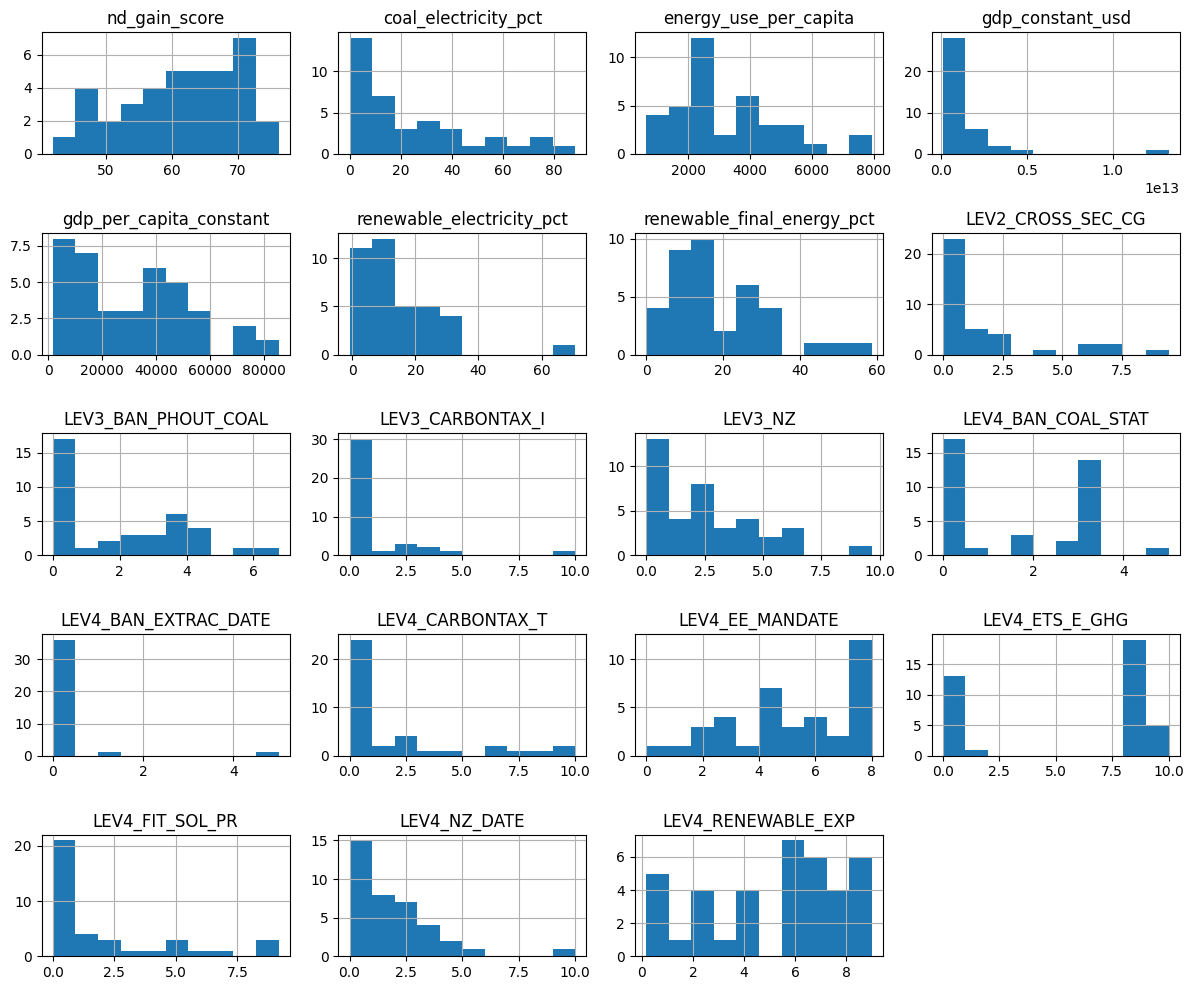

In [4]:
# Simple visualisation of distibution of og set


df_averaged.hist(figsize=(12, 10))
plt.tight_layout()
plt.show()


New Mean (should be ~0): 9.228152252814019e-15
New Std (should be ~1): 1.0134234194190632


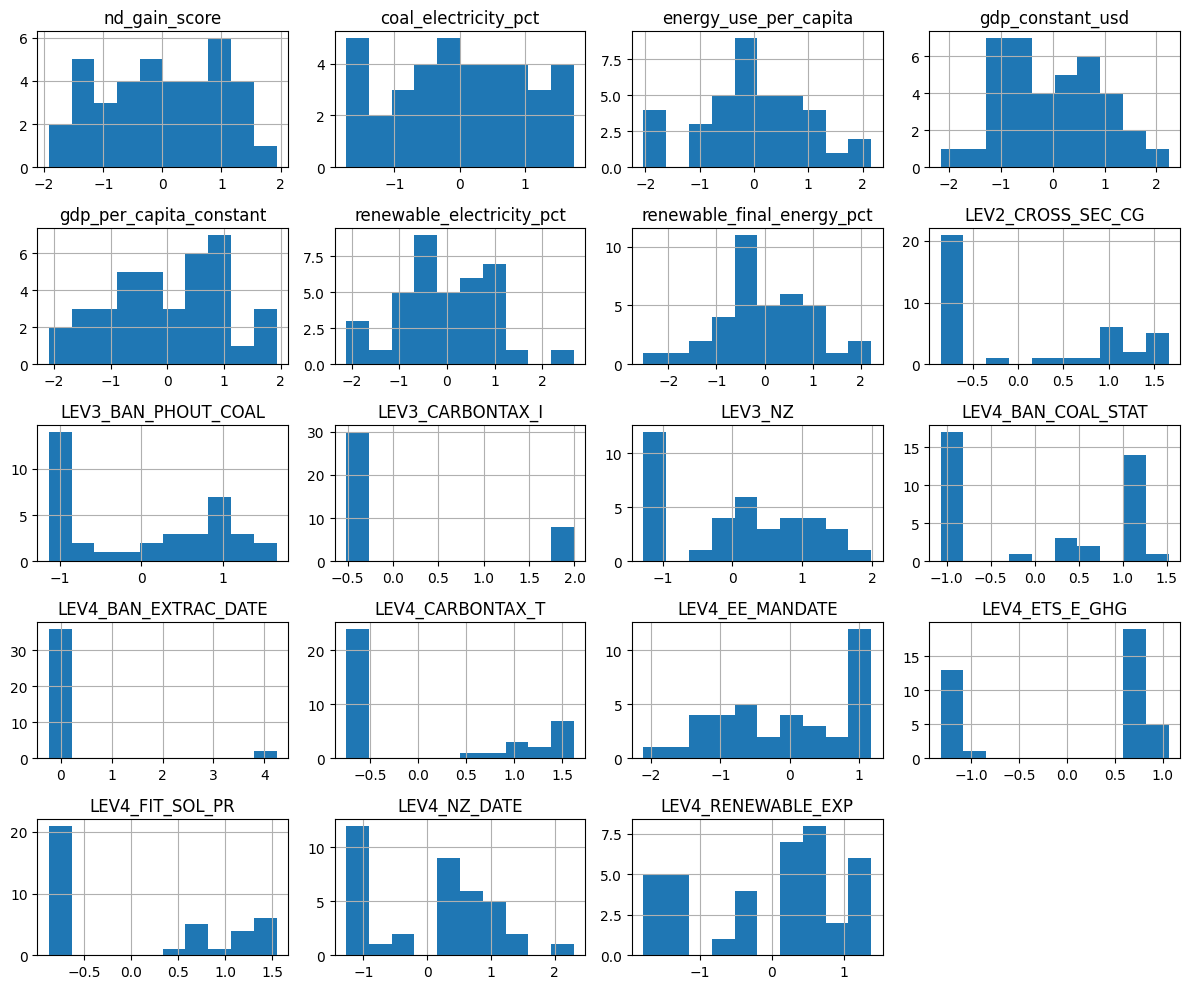

In [8]:


from sklearn.preprocessing import StandardScaler, PowerTransformer
# Apply PowerTransformer (Yeo-Johnson) 
pt = PowerTransformer(method='yeo-johnson')
X_transformed = pt.fit_transform(X)


# Convert to DataFrame to check results
X_df = pd.DataFrame(X_transformed, columns=X.columns)
print("New Mean (should be ~0):", X_df.mean().mean())
print("New Std (should be ~1):", X_df.std().mean())


# Simple visualisation of distibution of og set

X_df.hist(figsize=(12, 10))
plt.tight_layout()
plt.show()



Text(0.5, 1.0, 'Feature Redundancy Audit')

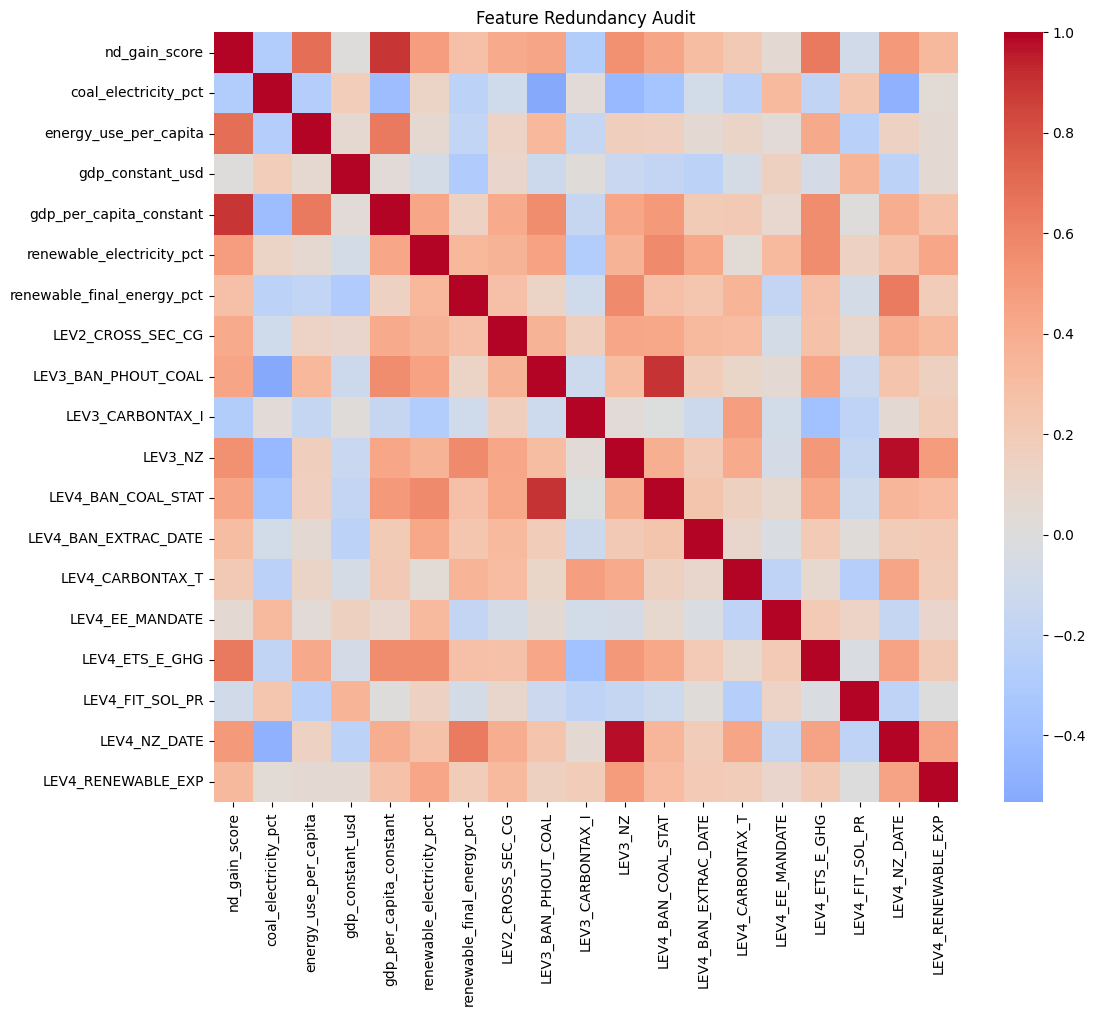

In [10]:
import seaborn as sns

plt.figure(figsize=(12, 10))
sns.heatmap(X_df.corr(), cmap='coolwarm', center=0)
plt.title("Feature Redundancy Audit")